In [1]:
import gurobipy as gp
import math
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
import re
import os
import shutil

In [2]:
# output generation for paper 3

In [3]:
# get input paths
test_set = "miplib3" # todo update this as needed
instance_fldr = os.path.join("instances", test_set)
test_set_fldr = os.path.join("test_sets", test_set)
results_fldr = os.path.join("results", test_set)
out_fldr = os.path.join("outputs", test_set)

# set filters
seed_idxs = [0]  
max_indices = 2
degrees = [-1, 1]  # todo update this as needed
term_list = [64]  # todo update this as needed
filter_cbc = False
max_base_std = 1e10
min_termination_time = 0  # todo update this as needed - fitler wins on default runs that took at least 10 seconds
short, medium, long = 60, 600, 3600
remove_status_changes = False
win_threshold = .2
filter_redundant = True

default_generators = ["None"]
test_generators = ["Farkas", "NoDisjunction", "DisjWarmStart"]
generators = default_generators + test_generators
disjunctive_generators = [g for g in generators if g != "None"]
parametric_generators = [g for g in generators if g not in ["None", "New"]]
cut_generators = [g for g in generators if g not in ["None", "DisjWarmStart"]]


# set up some mappings
cat_map_new_lines = {
    "None": "Default",
    "Farkas": "Param Disj,\nParam Cuts",
    "Old": "Param Disj,\nCalc Cuts",
    "New": "Calc Disj,\nCalc Cuts",
    "NoDisjunction": "Support",
    "DisjWarmStart": "Disjunctive\nWarm Start",
}
cat_map = {
    "None": "Default",
    "Farkas": "Param Disj, Param Cuts",
    "Old": "Param Disj, Calc Cuts",
    "New": "Calc Disj, Calc Cuts",
    "NoDisjunction": "Support",
    "DisjWarmStart": "Disjunctive Warm Start",
}
perturbation_map = {
    "matrix": "Coefficient Matrix",
    "rhs": "Right Hand Side",
    "objective": "Objective"
}
label = {
    "postRootTime": "Time after Processing Root nodes",
    "rootDualBoundTimeSansVpc": "Root Processing Time (Minus VPC Generation)",
    "terminationTimeSansVpc": "Time (Minus VPC Generation)",
    "terminationTime": "Time",
    "nodes": "Nodes Processed",
    "iterations": "LP iterations",
}
unit = {
    "postRootTime": "(seconds)",
    "rootDualBoundTimeSansVpc": "(seconds)",
    "terminationTimeSansVpc": "(seconds)",
    "terminationTime": "(seconds)",
    "nodes": "(1000 nodes)",
    "iterations": "(1000 iterations)",
}
limits = {
    "postRootTime": 7200,
    "terminationTimeSansVpc": 7200,
    "terminationTime": 7200,
    "rootDualBoundTimeSansVpc": 5,
    "nodes": 10000,
    "iterations": 37500
}
bracket_bounds = {
    "short": (min_termination_time, short),
    "medium": (short, medium),
    "long": (medium, long)
}
param_map = {
    "degree": "Degree of Perturbation",
    "terms": "Number of Disjunctive Terms",
}

In [4]:
# matplotlib settings
plt.rc('text', usetex=True)  # use latex fonts
plt.rcParams['font.size'] = 18
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14

## Check run failures

In [5]:
# check if each folder in test_set_fldr has a corresponding .mps file in instance_fldr
# for instance in os.listdir(test_set_fldr):
#     if not os.path.isdir(os.path.join(test_set_fldr, instance)):
#         continue
#     if not os.path.exists(os.path.join(instance_fldr, f"{instance}.mps")):
#         # remove the folder if the instance is missing
#         # shutil.rmtree(os.path.join(test_set_fldr, instance))
#         print(f"Removed {instance} from test set")

In [6]:
# running list of strings contained by different error codes
# last two are catchalls
err = {
    "walltime": [],
    "bad_alloc": [],
    "out of memory": [],
    "vmem": [],
    "takeoffcuts": [],
    "solver is dual infeasible": [],
    "solver must be optimal": [],
    "segmentation fault": [],
    "no vpcs were made from a new disjunction": [],
    "must have primalbound >= root lp objective": [],
    "objective at parent nodes": [],
    "failed to optimize mip": [],
    "disjunction does not represent a full binary tree": [],
    "solver not proven optimal for nodes": [],
    "unable to open": [],
    "license": [],
    "dot product with obj differs from solver": [],
    "gurobi: error during callback: addCut": [],
    "cglvpc::setupconstraints: objective at disjunctive term": [],
    "unable to read file": [],
    "stats.id == stats_vec": [],
    "size of our disjunction is not what we expected it to be": [],
    "dimension must stay fixed": [],
    "vpcgenerator must be": [],
    "objective values must match": [],
    "objective at disjunctive term": [],
    "libmkl_intel_lp64.so": [],
    "aborted": [],
    "solution is not feasible": [],
    "objective value does not match": [],
}

# read in cbc acceptable instances from cbc.txt
with open("cbc.txt", "r") as f:
    cbc_instances = f.read().split("\n")

# runs that errored out with new error code
other = []

# runs that had no errors
empty = []

# runs that only had warnings
warn_strs = ["warning", "prlp is primal infeasible", "farkas", "x:", "x[", "b:",
             "b[", "v:", "v[", "cut:", "A_i . x", "dot product with obj differs from solver"]
warning = []

# series that didn't run
no_go = []

# track sizes of instances
rows, cols, density = {}, {}, {}

# map the names
names = {}

# counts
count_series = 0
count_instances = 0
number_instances = {}

# iterate over all expected runs
for instance in os.listdir(test_set_fldr):
    if not os.path.isdir(os.path.join(test_set_fldr, instance)):
        continue
    # only look at cbc instances if we ran with cbc
    if instance not in cbc_instances and "gurobi" not in test_set and filter_cbc:
        continue
        
    # get the number of rows and columns in the instance
    mdl = gp.read(os.path.join(instance_fldr, f"{instance}.mps"))
    rows[instance] = mdl.NumConstrs
    cols[instance] = mdl.NumVars
    density[instance] = mdl.NumNZs / (mdl.NumConstrs * mdl.NumVars)
        
    for perturbation in os.listdir(os.path.join(test_set_fldr, instance)):
        if not os.path.isdir(os.path.join(test_set_fldr, instance, perturbation)):
            continue
        # only look at perturbations that were run
        p, d = perturbation.split("_")
        if int(d) not in degrees or p not in perturbation_map:
            continue
        for terms in term_list:
            for generator in generators:
                for seed_idx in seed_idxs:

                    # set variables for this iterations
                    count_series += 1
                    stem = f"{instance}_{perturbation}_{terms}_{generator}_{seed_idx}"
                    file_pth = os.path.join(results_fldr, f"{stem}.err")
                    series_fldr = os.path.join(test_set_fldr, instance, perturbation)
                    current_count = len([f for f in os.listdir(series_fldr) if f.endswith(".mps")])
                    count_instances += current_count
                    names[stem] = instance
                    number_instances[stem] = {
                        "expected": current_count,
                        "recorded": 0,
                        "generator": generator,
                        "error": "N/A"
                    }
    
                    # check if the series wasn't run
                    if not os.path.exists(file_pth):
                        number_instances[stem]["error"] = "no go"
                        no_go.append(stem)
                    
                    # check if the series ran with no errors or warnings
                    elif os.path.getsize(file_pth) == 0:
                        number_instances[stem]["error"] = "empty"
                        empty.append(stem)
                    
                    # track which error codes were thrown
                    else:
                        # read the file
                        with open(file_pth, "r") as f:
                            text = f.read().lower()
                        
                        # assign the error file to the appropriate list
                        found_code = False
                        for code in err:
                            if code in text:
                                if code == "dot product with obj differs from solver":
                                    pattern = r"obj viol from solver: (-?\d+\.\d+)\. calculated: (-?\d+\.\d+)"
                                    s, c = re.findall(pattern, text)[-1]
                                    # if we didn't terminate, this isn't an error, so keep going
                                    if abs(float(s) - float(c)) < 1e-3:
                                        continue
                                err[code].append(stem)
                                found_code = True
                                number_instances[stem]["error"] = code
                                break
                        if not found_code:
                            if all(not line or any(w in line for w in warn_strs) for line in text.splitlines()):
                                warning.append(stem)
                                number_instances[stem]["error"] = "warning"
                            else:
                                other.append(stem)
                                number_instances[stem]["error"] = "other"

Set parameter Username
Academic license - for non-commercial use only - expires 2026-08-25
Read MPS format model from file instances/miplib3/10teams.mps
Reading time = 0.00 seconds
10TEAMS: 230 rows, 2025 columns, 12150 nonzeros
Read MPS format model from file instances/miplib3/blend2.mps
Reading time = 0.00 seconds
blend2: 274 rows, 353 columns, 1409 nonzeros
Read MPS format model from file instances/miplib3/modglob.mps
Reading time = 0.00 seconds
MODGLOB: 291 rows, 422 columns, 968 nonzeros
Read MPS format model from file instances/miplib3/p2756.mps
Reading time = 0.00 seconds
P2756: 755 rows, 2756 columns, 8937 nonzeros
Read MPS format model from file instances/miplib3/qnet1_o.mps
Reading time = 0.00 seconds
QNET1_O: 456 rows, 1541 columns, 4214 nonzeros
Read MPS format model from file instances/miplib3/mas74.mps
Reading time = 0.00 seconds
MAS74: 13 rows, 151 columns, 1706 nonzeros
Read MPS format model from file instances/miplib3/qnet1.mps
Reading time = 0.00 seconds
QNET1: 503 ro

In [7]:
# check which series didn't run
print(no_go)

['modglob_rhs_1_64_None_0', 'modglob_rhs_1_64_Farkas_0', 'modglob_rhs_1_64_NoDisjunction_0', 'modglob_rhs_1_64_DisjWarmStart_0', 'modglob_objective_1_64_None_0', 'modglob_objective_1_64_Farkas_0', 'modglob_objective_1_64_NoDisjunction_0', 'modglob_objective_1_64_DisjWarmStart_0', 'modglob_rhs_-1_64_None_0', 'modglob_rhs_-1_64_Farkas_0', 'modglob_rhs_-1_64_NoDisjunction_0', 'modglob_objective_-1_64_None_0', 'modglob_objective_-1_64_Farkas_0', 'modglob_objective_-1_64_NoDisjunction_0', 'modglob_objective_-1_64_DisjWarmStart_0', 'qnet1_o_objective_1_64_None_0', 'qnet1_o_objective_1_64_Farkas_0', 'qnet1_o_objective_1_64_NoDisjunction_0', 'qnet1_o_objective_1_64_DisjWarmStart_0', 'qnet1_rhs_1_64_None_0', 'qnet1_rhs_1_64_Farkas_0', 'qnet1_rhs_1_64_NoDisjunction_0', 'qnet1_rhs_1_64_DisjWarmStart_0', 'qnet1_objective_1_64_None_0', 'qnet1_objective_1_64_Farkas_0', 'qnet1_objective_1_64_NoDisjunction_0', 'qnet1_objective_1_64_DisjWarmStart_0', 'qnet1_rhs_-1_64_None_0', 'qnet1_rhs_-1_64_Farkas_0'

In [8]:
# get the proportion of series that at least got started
1 - (len(no_go) / count_series)

0.8190104166666666

In [9]:
# out of time - got hung up in code somewhere - ok
print(err["walltime"])
len(err["walltime"]) / count_series

['mas74_rhs_1_64_None_0', 'mas74_rhs_1_64_Farkas_0', 'mas74_rhs_1_64_NoDisjunction_0', 'mas74_rhs_1_64_DisjWarmStart_0', 'mas74_objective_1_64_None_0', 'mas74_objective_1_64_Farkas_0', 'mas74_objective_1_64_NoDisjunction_0', 'mas74_objective_1_64_DisjWarmStart_0', 'mas74_rhs_-1_64_None_0', 'mas74_objective_-1_64_None_0', 'mas74_objective_-1_64_Farkas_0', 'mas74_objective_-1_64_NoDisjunction_0', 'mas74_objective_-1_64_DisjWarmStart_0', 'qnet1_rhs_-1_64_DisjWarmStart_0', 'gt2_objective_-1_64_None_0']


0.01953125

In [10]:
# out of memory - memory is maxed already - this is what it is
# todo: figure out where we ran short on memory so we can explain why we dropped them
print(err["bad_alloc"] + err["out of memory"] + err["vmem"])
len(err["bad_alloc"] + err["out of memory"] + err["vmem"]) / count_series

[]


0.0

In [11]:
# rerun this if want to give more memory to some instances
# bad_alloc_names = set(n.split("_")[0] for n in err["bad_alloc"])
# mem = pd.read_csv("more_memory.csv", index_col=0)
# mem["reason"] = "hard solve" 
# 
# for n in bad_alloc_names:
#     if f"{n}.mps" not in mem.index:
#         new_row = pd.DataFrame([{'file_name': f"{n}.mps", 'memory': 16.0, 'reason': 'big disjunction'}]).set_index('file_name')
#         mem = pd.concat([mem, new_row])
#     else:
#         mem.loc[f'{n}.mps', 'memory'] = 16.0
# 
# mem.to_csv("more_memory.csv")

In [12]:
# this is an issue with John's bookkeeping - not much we can do here
print(err["takeoffcuts"])
len(err["takeoffcuts"]) / count_series

[]


0.0

In [13]:
print(err["solver is dual infeasible"])
len(err["solver is dual infeasible"]) / count_series

[]


0.0

In [14]:
# these are usually issues with CLP finding optimality - not much we can do here
print(err["solver must be optimal"])
len(err["solver must be optimal"]) / count_series

[]


0.0

In [15]:
print(err["segmentation fault"])
len(err["segmentation fault"]) / count_series

['vpm1_objective_1_64_DisjWarmStart_0', 'vpm1_rhs_-1_64_DisjWarmStart_0', 'vpm1_objective_-1_64_DisjWarmStart_0', 'p0548_rhs_1_64_DisjWarmStart_0', 'pk1_rhs_1_64_DisjWarmStart_0', 'pk1_objective_1_64_DisjWarmStart_0', 'pk1_rhs_-1_64_DisjWarmStart_0', 'pk1_objective_-1_64_DisjWarmStart_0']


0.010416666666666666

In [16]:
# seg_err = {
#     "Bad image at line": [],
# }
# 
# seg_other = []
# 
# for stem in err["segmentation fault"]:
#     file_pth = os.path.join(results_fldr, f"{stem}.out")
# 
#     with open(file_pth, "r") as f:
#         text = f.read()
#     
#     # assign the error file to the appropriate list
#     found_code = False
#     for code in seg_err:
#         if code in text:
#             seg_err[code].append(stem)
#             found_code = True
#             break
#     if not found_code:
#         seg_other.append(stem)

In [17]:
# print(seg_err["Bad image at line"])
# len(seg_err["Bad image at line"]) / len(err["segmentation fault"]) if err["segmentation fault"] else 0

In [18]:
# print(seg_other)
# len(seg_other)/len(err["segmentation fault"]) if err["segmentation fault"] else 0

In [19]:
# # get breakdown of why vpc generation failed - mostly from lack of provisioning
# for code, exps in seg_err.items():
#     print(f"{code}: {len(exps) / len(err['segmentation fault']) if err['segmentation fault'] else 0}")
# 
# print(f"other: {len(seg_other) / len(err['segmentation fault']) if err['segmentation fault'] else 0}")

In [20]:
# todo: check aleks' removals and drop those below for similar reasons
# todo: check size of disjunctions and decide what to do with those that are too big
# these should all be from the problem being too big and hitting the time limit or integer solutions
print(err["no vpcs were made from a new disjunction"])
missing_4_term = [n for n in err["no vpcs were made from a new disjunction"] if "_4_" in n]
missing_64_term = [n for n in err["no vpcs were made from a new disjunction"] if "_64_" in n]
print(f'4 term: {len(missing_4_term) / count_series}')
print(f'64 term: {len(missing_64_term) / count_series}')

['10teams_rhs_1_64_Farkas_0', '10teams_rhs_1_64_NoDisjunction_0', '10teams_objective_1_64_Farkas_0', '10teams_objective_1_64_NoDisjunction_0', '10teams_rhs_-1_64_Farkas_0', '10teams_rhs_-1_64_NoDisjunction_0', '10teams_objective_-1_64_Farkas_0', '10teams_objective_-1_64_NoDisjunction_0', 'p2756_objective_1_64_Farkas_0', 'p2756_objective_1_64_NoDisjunction_0', 'p2756_rhs_-1_64_Farkas_0', 'p2756_rhs_-1_64_NoDisjunction_0', 'p2756_objective_-1_64_Farkas_0', 'p2756_objective_-1_64_NoDisjunction_0', 'mod010_rhs_1_64_Farkas_0', 'mod010_rhs_1_64_NoDisjunction_0', 'mod010_objective_1_64_Farkas_0', 'mod010_objective_1_64_NoDisjunction_0', 'mod010_rhs_-1_64_Farkas_0', 'mod010_rhs_-1_64_NoDisjunction_0', 'mod010_objective_-1_64_Farkas_0', 'mod010_objective_-1_64_NoDisjunction_0', 'rentacar_rhs_-1_64_Farkas_0', 'rentacar_rhs_-1_64_NoDisjunction_0', 'rentacar_objective_-1_64_Farkas_0', 'rentacar_objective_-1_64_NoDisjunction_0', 'fixnet6_rhs_1_64_Farkas_0', 'fixnet6_rhs_1_64_NoDisjunction_0', 'fixn

In [21]:
# vpc_err = {
#     "CglVPC: Finishing with exit reason: PRLP_TIME_LIMIT": [],
#     "CglVPC: Finishing with exit reason: TIME_LIMIT": [],
#     "CglVPC: Finishing with exit reason: NO_CUTS_LIKELY": [],
#     "CglVPC: Finishing with exit reason: PRLP_INFEASIBLE": [],
#     "CglVPC: Finishing with exit reason: SUCCESS": [],
#     "CglVPC: Finishing with exit reason: OPTIMAL_SOLUTION_FOUND": [],
#     "CglVPC: Finishing with exit reason: FAIL_LIMIT": [],
#     "CglVPC: Finishing with exit reason: NO_DISJUNCTION": [],
# }
# 
# vpc_other = []
# 
# for stem in err["no vpcs were made from a new disjunction"]:
#     file_pth = os.path.join(results_fldr, f"{stem}.out")
# 
#     with open(file_pth, "r") as f:
#         text = f.read()
#     
#     # assign the error file to the appropriate list
#     found_code = False
#     for code in vpc_err:
#         if code in text:
#             vpc_err[code].append(stem)
#             found_code = True
#             break
#     if not found_code:
#         vpc_other.append(stem)

In [22]:
# print(vpc_err["CglVPC: Finishing with exit reason: PRLP_TIME_LIMIT"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: PRLP_TIME_LIMIT"]) / len(err["no vpcs were made from a new disjunction"])

In [23]:
# print(vpc_err["CglVPC: Finishing with exit reason: TIME_LIMIT"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: TIME_LIMIT"]) / len(err["no vpcs were made from a new disjunction"])

In [24]:
# print(vpc_err["CglVPC: Finishing with exit reason: NO_CUTS_LIKELY"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: NO_CUTS_LIKELY"]) / len(err["no vpcs were made from a new disjunction"])

In [25]:
# print(vpc_err["CglVPC: Finishing with exit reason: PRLP_INFEASIBLE"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: PRLP_INFEASIBLE"]) / len(err["no vpcs were made from a new disjunction"])

In [26]:
# print(vpc_err["CglVPC: Finishing with exit reason: SUCCESS"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: SUCCESS"]) / len(err["no vpcs were made from a new disjunction"])

In [27]:
# print(vpc_err["CglVPC: Finishing with exit reason: OPTIMAL_SOLUTION_FOUND"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: OPTIMAL_SOLUTION_FOUND"]) / len(err["no vpcs were made from a new disjunction"])

In [28]:
# print(vpc_err["CglVPC: Finishing with exit reason: FAIL_LIMIT"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: FAIL_LIMIT"]) / len(err["no vpcs were made from a new disjunction"])

In [29]:
# print(vpc_err["CglVPC: Finishing with exit reason: NO_DISJUNCTION"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: NO_DISJUNCTION"]) / len(err["no vpcs were made from a new disjunction"])

In [30]:
# vpc_other

In [31]:
# # get breakdown of why vpc generation failed - mostly from lack of provisioning/problem being too large
# if err["no vpcs were made from a new disjunction"]:
#     for code, exps in vpc_err.items():
#         print(f"{code}: {len(exps) / len(err['no vpcs were made from a new disjunction'])}")
#     
#     print(f"other: {len(vpc_other) / len(err['no vpcs were made from a new disjunction'])}")

In [32]:
print(err["must have primalbound >= root lp objective"])
len(err["must have primalbound >= root lp objective"]) / count_series

[]


0.0

In [33]:
# LP relaxation objective is not going to match root nodes objective when warm starting 
print(err["objective at parent nodes"])
len(err["objective at parent nodes"]) / count_series

[]


0.0

In [34]:
# not enough tolerance added to bound (or we hit time limit) - element 2 from 5 and 4 from 4
print(err["failed to optimize mip"])
len(err["failed to optimize mip"]) / count_series

[]


0.0

In [35]:
# todo: figure out why
print(err["disjunction does not represent a full binary tree"])
len(err["disjunction does not represent a full binary tree"]) / count_series

[]


0.0

In [36]:
# again issue with not getting through vpc generation in time
# todo: handle this gracefully
print(err["solver not proven optimal for nodes"])
len(err["solver not proven optimal for nodes"]) / count_series

[]


0.0

In [37]:
print(err["unable to open"])
len(err["unable to open"]) / count_series

[]


0.0

In [38]:
print(err["license"])
len(err["license"]) / count_series

[]


0.0

In [39]:
print(warning)
len(warning) / count_series

[]


0.0

In [40]:
# blend 2 unsure, mas74 hits hour,
print(err["aborted"])  # symphony runs into an issue reusing the tree
len(err["aborted"]) / count_series

['mas74_rhs_-1_64_DisjWarmStart_0', 'gesa2_o_objective_1_64_DisjWarmStart_0', 'gesa2_o_rhs_-1_64_Farkas_0', 'gesa2_o_rhs_-1_64_NoDisjunction_0', 'gesa2_o_rhs_-1_64_DisjWarmStart_0', 'gesa2_o_objective_-1_64_DisjWarmStart_0', 'vpm1_objective_1_64_None_0', 'vpm1_objective_1_64_Farkas_0', 'vpm1_objective_1_64_NoDisjunction_0', 'vpm1_rhs_-1_64_None_0', 'vpm1_rhs_-1_64_Farkas_0', 'vpm1_rhs_-1_64_NoDisjunction_0', 'vpm1_objective_-1_64_None_0', 'vpm1_objective_-1_64_Farkas_0', 'vpm1_objective_-1_64_NoDisjunction_0', 'pp08a_rhs_1_64_None_0', 'pp08a_rhs_1_64_Farkas_0', 'pp08a_rhs_1_64_NoDisjunction_0', 'pp08a_rhs_1_64_DisjWarmStart_0', 'pp08a_objective_1_64_None_0', 'pp08a_objective_1_64_Farkas_0', 'pp08a_objective_1_64_NoDisjunction_0', 'pp08a_rhs_-1_64_None_0', 'pp08a_rhs_-1_64_Farkas_0', 'pp08a_rhs_-1_64_NoDisjunction_0', 'pp08a_rhs_-1_64_DisjWarmStart_0', 'markshare1_rhs_1_64_None_0', 'markshare1_rhs_1_64_Farkas_0', 'markshare1_rhs_1_64_NoDisjunction_0', 'markshare1_rhs_1_64_DisjWarmStart_

0.11588541666666667

In [41]:
print(err["solution is not feasible"])
len(err["solution is not feasible"]) / count_series

['mas74_rhs_-1_64_Farkas_0', 'mas74_rhs_-1_64_NoDisjunction_0', 'dsbmip_rhs_-1_64_None_0', 'dsbmip_rhs_-1_64_DisjWarmStart_0', 'dsbmip_objective_-1_64_DisjWarmStart_0', 'arki001_objective_1_64_None_0', 'arki001_objective_1_64_DisjWarmStart_0', 'arki001_rhs_-1_64_None_0', 'arki001_rhs_-1_64_DisjWarmStart_0', 'arki001_objective_-1_64_None_0', 'arki001_objective_-1_64_DisjWarmStart_0', 'gesa2_objective_1_64_None_0', 'gesa2_objective_1_64_DisjWarmStart_0', 'gesa2_rhs_-1_64_None_0', 'gesa2_rhs_-1_64_DisjWarmStart_0', 'gesa2_objective_-1_64_None_0', 'gesa2_objective_-1_64_DisjWarmStart_0', 'mas76_rhs_1_64_Farkas_0', 'mas76_rhs_1_64_NoDisjunction_0', 'mas76_objective_1_64_Farkas_0', 'mas76_objective_1_64_NoDisjunction_0', 'qiu_rhs_1_64_None_0', 'qiu_rhs_1_64_DisjWarmStart_0', 'qiu_objective_1_64_None_0', 'qiu_objective_1_64_DisjWarmStart_0', 'qiu_rhs_-1_64_None_0', 'qiu_rhs_-1_64_DisjWarmStart_0', 'qiu_objective_-1_64_None_0', 'qiu_objective_-1_64_DisjWarmStart_0', 'gesa3_o_objective_1_64_Non

0.048177083333333336

In [42]:
print(err["objective value does not match"])
len(err["objective value does not match"]) / count_series

['10teams_rhs_1_64_None_0', '10teams_rhs_1_64_DisjWarmStart_0', '10teams_objective_1_64_None_0', '10teams_objective_1_64_DisjWarmStart_0', '10teams_rhs_-1_64_None_0', '10teams_rhs_-1_64_DisjWarmStart_0', '10teams_objective_-1_64_None_0', '10teams_objective_-1_64_DisjWarmStart_0', 'modglob_rhs_-1_64_DisjWarmStart_0', 'p2756_objective_1_64_None_0', 'p2756_objective_1_64_DisjWarmStart_0', 'p2756_rhs_-1_64_None_0', 'p2756_rhs_-1_64_DisjWarmStart_0', 'p2756_objective_-1_64_None_0', 'p2756_objective_-1_64_DisjWarmStart_0', 'mod010_rhs_1_64_None_0', 'mod010_rhs_1_64_DisjWarmStart_0', 'mod010_objective_1_64_None_0', 'mod010_objective_1_64_DisjWarmStart_0', 'mod010_rhs_-1_64_None_0', 'mod010_rhs_-1_64_DisjWarmStart_0', 'mod010_objective_-1_64_None_0', 'mod010_objective_-1_64_DisjWarmStart_0', 'rentacar_objective_1_64_DisjWarmStart_0', 'rentacar_rhs_-1_64_None_0', 'rentacar_rhs_-1_64_DisjWarmStart_0', 'rentacar_objective_-1_64_None_0', 'rentacar_objective_-1_64_DisjWarmStart_0', 'fixnet6_rhs_1_6

0.16536458333333334

In [43]:
# errors unaccounted for
print(other)
len(other) / count_series

[]


0.0

In [44]:
print(err["libmkl_intel_lp64.so"])
len(err["libmkl_intel_lp64.so"]) / count_series

[]


0.0

In [45]:
# proportion of series that were improperly provisioned
(len(err["bad_alloc"] + err["out of memory"] + err["walltime"] + err["vmem"])) / count_series

0.01953125

In [46]:
print(err["dot product with obj differs from solver"])
len(err["dot product with obj differs from solver"]) / count_series

[]


0.0

In [47]:
# changed code to ignore this error
print(err["gurobi: error during callback: addCut"])
len(err["gurobi: error during callback: addCut"]) / count_series

[]


0.0

In [48]:
# largely not replicating - only issue I could find was aleks missing updated objective from CLP when resolving to check this
print(err["cglvpc::setupconstraints: objective at disjunctive term"])
len(err["cglvpc::setupconstraints: objective at disjunctive term"]) / count_series

[]


0.0

In [49]:
# not replicating - rerun
print(err["unable to read file"])
len(err["unable to read file"]) / count_series

[]


0.0

In [50]:
# not replicating - rerun
print(err["stats.id == stats_vec"])
len(err["stats.id == stats_vec"]) / count_series

[]


0.0

In [51]:
print(err["size of our disjunction is not what we expected it to be"])
len(err["size of our disjunction is not what we expected it to be"]) / count_series

[]


0.0

In [52]:
print(err["vpcgenerator must be"])
len(err["vpcgenerator must be"]) / count_series

[]


0.0

In [53]:
print(err["dimension must stay fixed"])
len(err["dimension must stay fixed"]) / count_series

[]


0.0

In [54]:
print(err["objective values must match"])
len(err["objective values must match"]) / count_series

[]


0.0

In [55]:
print(err["objective at disjunctive term"])
len(err["objective at disjunctive term"]) / count_series

[]


0.0

In [56]:
# get breakdown of errors
for code, exps in err.items():
    print(f"{code}: {len(exps) / count_series}")

print(f"other: {len(other) / count_series}")

print(f"warning: {len(warning) / count_series}")

print(f"no errors/warnings: {len(empty) / count_series}")

print(f"no go: {len(no_go) / count_series}")

walltime: 0.01953125
bad_alloc: 0.0
out of memory: 0.0
vmem: 0.0
takeoffcuts: 0.0
solver is dual infeasible: 0.0
solver must be optimal: 0.0
segmentation fault: 0.010416666666666666
no vpcs were made from a new disjunction: 0.21354166666666666
must have primalbound >= root lp objective: 0.0
objective at parent nodes: 0.0
failed to optimize mip: 0.0
disjunction does not represent a full binary tree: 0.0
solver not proven optimal for nodes: 0.0
unable to open: 0.0
license: 0.0
dot product with obj differs from solver: 0.0
gurobi: error during callback: addCut: 0.0
cglvpc::setupconstraints: objective at disjunctive term: 0.0
unable to read file: 0.0
stats.id == stats_vec: 0.0
size of our disjunction is not what we expected it to be: 0.0
dimension must stay fixed: 0.0
vpcgenerator must be: 0.0
objective values must match: 0.0
objective at disjunctive term: 0.0
libmkl_intel_lp64.so: 0.0
aborted: 0.11588541666666667
solution is not feasible: 0.048177083333333336
objective value does not matc

## Read in data

In [56]:
# map generator names to the corresponding data frames
df_map = {g: pd.DataFrame() for g in generators} 
gap_map = {g: pd.DataFrame() for g in generators}
regex = re.compile(r'([a-zA-Z0-9-]+(?:_o)?)_([a-z]+)_([0-9-]+)_([0-9]+)_([a-zA-Z ]+)')
solution_pattern = r"_(\d+)\.pb"

# declaring types as needed
column_types = {
    "lpBound": float,
    "lpBoundPostVpc": float,
    "disjunctiveDualBound": float,
    "primalBound": float,
    "rootDualBound": float,
    "dualBound": float
}

skipped_instances = set()
primal_bounds = {}
same_solution = {}

# iterate over all files in the folder
for file_name in os.listdir(results_fldr):
    
    file_pth = os.path.join(results_fldr, file_name)
    
    # if the file is not a nonempty csv, skip it
    if not file_name.endswith(".csv") or os.path.getsize(file_pth) == 0:
        continue
    
    # get the experimental set up
    match = regex.search(file_name)
    instance_name = names.get(file_name[:-4])
    if not instance_name:
        skipped_instances.add(file_name[:-4].split("_")[0])
        os.remove(file_pth)
        continue
    # instance_name = match.group(1)
    perturbation = match.group(2)
    assert perturbation in ["matrix", "rhs", "bound", "objective"], f"Unknown perturbation: {perturbation}"
    expo = int(match.group(3))
    assert expo in degrees, f"Unknown degree: {expo}"
    degree = 2**int(expo)
    terms = int(match.group(4))
    assert terms in term_list, f"Unknown number of terms: {terms}"
    generator = match.group(5)
    assert generator in generators, f"Unknown generator: {generator}"
    base_name = f"{instance_name}_0"
    
    # get the primal bounds for this experiment
    cur_instance_test_set_fldr = os.path.join(test_set_fldr, instance_name, f"{perturbation}_{expo}")
    for test_set_file in os.listdir(cur_instance_test_set_fldr):
        if test_set_file.endswith(".pb"):
            with open(os.path.join(cur_instance_test_set_fldr, test_set_file), "r") as f:
                primal_bounds[perturbation, expo, ".".join(test_set_file.split(".")[:-1])] = float(f.read())
                
    # see if solution changed
    for test_set_file in os.listdir(cur_instance_test_set_fldr):
        if test_set_file.endswith(".pb"):
            perturbation_name = ".".join(test_set_file.split(".")[:-1])
            same_solution[perturbation, expo, perturbation_name] = \
                primal_bounds[perturbation, expo, base_name] == primal_bounds[perturbation, expo, perturbation_name]
            
    # read the file
    df = pd.read_csv(file_pth, keep_default_na=False, dtype=column_types, index_col=0)
    
    for instance_idx in df.index:
        
        # fill in primal bounds if missing
        # df.loc[instance_idx, "primalBound"] = min(primal_bounds.get(stem_map.get(instance_idx), 1e100), df.loc[instance_idx, "primalBound"])
        df.loc[instance_idx, "primalBound"] = min(
            primal_bounds[perturbation, expo, f"{instance_name}_{instance_idx}"], df.loc[instance_idx, "primalBound"]
        )
        
        # same with root dual bound
        df.loc[instance_idx, "rootDualBound"] = df.loc[instance_idx, "rootDualBound"] if df.loc[instance_idx, "rootDualBound"] < 1e100 else df.loc[instance_idx, "lpBoundPostVpc"] 
    
    # get rid of the index so the rest of the notebook works
    df.reset_index(inplace=True)
    
    # add some identifying columns
    df["instance"] = instance_name
    df["perturbation"] = perturbation
    df["degree"] = degree
    df["terms"] = terms
    df["rows"] = rows[instance_name]
    df["cols"] = cols[instance_name]
    df["density"] = density[instance_name]
    
    # append to the appropriate data frame
    df_map[generator] = pd.concat([df_map[generator], df])
    
    # track recorded vs expected experiments
    number_instances[file_name[:-4]]["recorded"] = len(df)

In [57]:
# convert number_instances to dataframe
frame = pd.DataFrame(number_instances).T
frame.head()

,expected,recorded,generator,error
10teams_rhs_1_64_None_0,2,2,None,empty
10teams_rhs_1_64_Farkas_0,2,2,Farkas,warning
10teams_rhs_1_64_NoDisjunction_0,2,2,NoDisjunction,empty
10teams_rhs_1_64_DisjWarmStart_0,2,2,DisjWarmStart,empty
10teams_objective_1_64_None_0,2,2,None,empty


In [58]:
# redo the runs that have incomplete data that we're not sure should be that way
redos = frame.loc[(frame["expected"] > frame["recorded"]) & (frame["error"] != "no vpcs were made from a new disjunction")].index.tolist()
redos = pd.DataFrame({"experiment": redos})
redos.to_csv("redos.csv", index=False)

In [59]:
if "miplib" in test_set or "quick" in test_set:
    # group frame by generator and sum remaining columns
    gb = frame.groupby(["generator", "error"]).sum().reset_index()
    gb["missing"] = gb["expected"] - gb["recorded"]
    total = gb.groupby("generator")[["expected", "missing"]].sum().reset_index()
    gb = pd.merge(gb, total, on="generator", suffixes=("", " total"))
    gb["ratio missing (by generator)"] = gb["missing"] / gb["missing total"]
    gb["ratio missing (by generator)"] = gb["ratio missing (by generator)"].apply(lambda x: round(x, 4))
    gb = gb.loc[:, ~gb.columns.str.contains("total")]  # get rid of the total columns
    gb.set_index(["generator", "error"], inplace=True)
    gb.to_csv(os.path.join(out_fldr, "missing_table.csv"), index=False, mode="w")
else:
    gb = None
gb

expected recorded  \
generator     error                                                        
DisjWarmStart aborted                                        16        0   
              empty                                         328      252   
              segmentation fault                             10        4   
              solution is not feasible                       26        2   
              walltime                                        4        4   
Farkas        aborted                                        10        0   
              empty                                         276      238   
              no vpcs were made from a new disjunction       82        0   
              segmentation fault                              4        0   
              solution is not feasible                        2        0   
              warning                                        10        4   
NoDisjunction aborted                                        12        0   
              empty                                         276      237   
              no vpcs were made from a new disjunction       82        0   
              solution is not feasible                        4        2   
              warning                                        10        4   
None          aborted                                        10        0   
              empty                                         344      289   
              segmentation fault                              4        0   
              solution is not feasible                       26        0   

                                                       missing  \
generator     error                                              
DisjWarmStart aborted                                       16   
              empty                                         76   
              segmentation fault                             6   
              solution is not feasible                      24   
              walltime                                       0   
Farkas        aborted                                       10   
              empty                                         38   
              no vpcs were made from a new disjunction      82   
              segmentation fault                             4   
              solution is not feasible                       2   
              warning                                        6   
NoDisjunction aborted                                       12   
              empty                                         39   
              no vpcs were made from a new disjunction      82   
              solution is not feasible                       2   
              warning                                        6   
None          aborted                                       10   
              empty                                         55   
              segmentation fault                             4   
              solution is not feasible                      26   

                                                        ratio missing (by generator)  
generator     error                                                                   
DisjWarmStart aborted                                                         0.1311  
              empty                                                           0.6230  
              segmentation fault                                              0.0492  
              solution is not feasible                                        0.1967  
              walltime                                                        0.0000  
Farkas        aborted                                                         0.0704  
              empty                                                           0.2676  
              no vpcs were made from a new disjunction                        0.5775  
              segmentation fault                           

In [60]:
masks = {}
for gen in generators:
    print(gen)
    masks[gen] = {
        0: -1e20 > df_map[gen]["lpBound"],
        1: df_map[gen]["lpBound"] - 1e-3 > df_map[gen]["lpBoundPostVpc"],
        2: ((df_map[gen]["lpBoundPostVpc"] - 1e-3 > df_map[gen]["disjunctiveDualBound"]) & (gen in cut_generators)),
        3: df_map[gen]["rootDualBound"] - 1e-3 > df_map[gen]["dualBound"],
        4: (df_map[gen]["dualBound"] - 1e-3 > df_map[gen]["primalBound"]) & (df_map[gen]["dualBound"] / df_map[gen]["primalBound"] > 1 + 1e-3),
        5: df_map[gen]["primalBound"] > 1e20,
        6: 0 > df_map[gen]["vpcGenerationTime"],
        7: df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["rootDualBoundTime"],
        8: df_map[gen]["rootDualBoundTime"] - 1e-3 > df_map[gen]["terminationTime"],
        9: df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["bestSolutionTime"],
        10: df_map[gen]["bestSolutionTime"] - 1e-3 > df_map[gen]["terminationTime"]
    }
    for i, mask in masks[gen].items():
        print(f"{gen} {i}: {mask.sum() / len(df_map[gen])}")

None
None 0: 0.0
None 1: 0.0
None 2: 0.0
None 3: 0.0034602076124567475
None 4: 0.03806228373702422
None 5: 0.0
None 6: 0.0
None 7: 0.0
None 8: 0.0
None 9: 0.0
None 10: 0.0
Farkas
Farkas 0: 0.0
Farkas 1: 0.0
Farkas 2: 0.0
Farkas 3: 0.004132231404958678
Farkas 4: 0.0
Farkas 5: 0.0
Farkas 6: 0.0
Farkas 7: 0.0
Farkas 8: 0.0
Farkas 9: 0.0
Farkas 10: 0.0
NoDisjunction
NoDisjunction 0: 0.0
NoDisjunction 1: 0.0
NoDisjunction 2: 0.0
NoDisjunction 3: 0.00411522633744856
NoDisjunction 4: 0.0
NoDisjunction 5: 0.0
NoDisjunction 6: 0.0
NoDisjunction 7: 0.0
NoDisjunction 8: 0.0
NoDisjunction 9: 0.0
NoDisjunction 10: 0.0
DisjWarmStart
DisjWarmStart 0: 0.0
DisjWarmStart 1: 0.0
DisjWarmStart 2: 0.0
DisjWarmStart 3: 0.23282442748091603
DisjWarmStart 4: 0.05343511450381679
DisjWarmStart 5: 0.0
DisjWarmStart 6: 0.0
DisjWarmStart 7: 0.0
DisjWarmStart 8: 0.0
DisjWarmStart 9: 0.0
DisjWarmStart 10: 0.0


In [61]:
# 3 dual bound takes -inf value
# 4 the bounds are just wrong
# these appear to be compile issues on coral - i don't get these errors on my machine
df_map["DisjWarmStart"].loc[masks["DisjWarmStart"][3]]

,instanceIndex,seedIndex,vpcGenerator,terms,lpBound,disjunctiveDualBound,lpBoundPostVpc,rootDualBound,dualBound,primalBound,...,tighten_infeasible_to_feasible_term,tighten_feasible_to_infeasible_basis,rootIterations,rootNodes,instance,perturbation,degree,rows,cols,density
1,1,0,DisjWarmStart,64,-7.921156e+03,-7.922914e+03,-7.921156e+03,-7.922914e+03,-8.086000e+03,-8.086000e+03,...,0,0,0,1227,fixnet6,objective,2.0,478,878,0.004184
1,1,0,DisjWarmStart,64,2.891793e+07,-1.674194e+06,2.891793e+07,-1.674194e+06,-2.309622e+08,-2.309622e+08,...,0,0,0,21,rentacar,objective,0.5,6803,9559,0.000643
1,1,0,DisjWarmStart,64,1.113563e+01,1.160678e+01,1.113563e+01,1.160678e+01,9.750000e+00,9.750000e+00,...,0,0,0,48913,vpm2,objective,2.0,234,378,0.010367
1,1,0,DisjWarmStart,64,9.786170e+02,-1.396633e+03,9.786170e+02,-1.396633e+03,-1.792644e+04,-1.792644e+04,...,0,0,0,1,rout,objective,0.5,291,556,0.015025
1,1,0,DisjWarmStart,64,1.099546e+05,1.902612e+04,1.099546e+05,1.902612e+04,-4.355915e+05,-4.355915e+05,...,0,0,0,1,gen,objective,2.0,780,870,0.003820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,1,0,DisjWarmStart,64,5.126178e+02,2.515119e+02,5.126178e+02,2.515119e+02,-1.874813e+03,-1.874813e+03,...,0,0,0,151,egout,objective,0.5,98,141,0.020408
1,1,0,DisjWarmStart,64,5.125894e+02,2.633997e+02,5.125894e+02,2.633997e+02,-1.850869e+03,-1.850869e+03,...,0,0,0,151,egout,rhs,2.0,98,141,0.020408
1,1,0,DisjWarmStart,64,4.790569e+03,4.794094e+03,4.790569e+03,4.794094e+03,4.719000e+03,4.719000e+03,...,0,0,0,27224,l152lav,rhs,0.5,97,1989,0.051427
1,1,0,DisjWarmStart,64,8.944941e+06,1.271109e+06,8.944941e+06,1.271109e+06,-5.250999e+07,-5.250999e+07,...,0,0,0,1110,bell5,objective,2.0,91,104,0.028107


In [62]:
for gen, df in df_map.items():
    print(f"{gen}: {df.size}")

None: 11560
Farkas: 9680
NoDisjunction: 9720
DisjWarmStart: 10480


In [63]:
# it shouldn't be possible that dual bound > primal bound. this only happens when we use the saved primal bound, which was used to set the dual bound
# df_map["Farkas"][masks[0]]

In [64]:
for gen in df_map:
    mask = (-1e20 > df_map[gen]["lpBound"]) | \
        (df_map[gen]["lpBound"] - 1e-3 > df_map[gen]["lpBoundPostVpc"]) | \
        ((df_map[gen]["lpBoundPostVpc"] - 1e-3 > df_map[gen]["disjunctiveDualBound"]) & (gen in cut_generators)) | \
        (df_map[gen]["rootDualBound"] - 1e-3 > df_map[gen]["dualBound"]) | \
        ((df_map[gen]["dualBound"] - 1e-3 > df_map[gen]["primalBound"]) & (df_map[gen]["dualBound"] / df_map[gen]["primalBound"] > 1 + 1e-3)) | \
        (df_map[gen]["primalBound"] > 1e20) | \
        (0 > df_map[gen]["vpcGenerationTime"]) | \
        (df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["rootDualBoundTime"]) | \
        (df_map[gen]["rootDualBoundTime"] - 1e-3 > df_map[gen]["terminationTime"]) | \
        (df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["bestSolutionTime"]) | \
        (df_map[gen]["bestSolutionTime"] - 1e-3 > df_map[gen]["terminationTime"])
    print(f"{gen}: {mask.sum() / len(df_map[gen])}")
    df_map[gen] = df_map[gen][~mask]

None: 0.04152249134948097
Farkas: 0.004132231404958678
NoDisjunction: 0.00411522633744856
DisjWarmStart: 0.2862595419847328


In [65]:
# merge the different data frames into one
join_cols = ["instance", "perturbation", "degree", "terms", "instanceIndex", "seedIndex"]
df = df_map[generators[0]].merge(df_map[generators[1]], on=join_cols, suffixes=(f" {generators[0]}", None))
for g1, g2 in zip(generators[1:-1], generators[2:]):
    df = df.merge(df_map[g2], on=join_cols, suffixes=(f" {g1}", None if g2 != generators[-1] else f" {g2}"))
df.head()

,instanceIndex,seedIndex,vpcGenerator None,terms,lpBound None,disjunctiveDualBound None,lpBoundPostVpc None,rootDualBound None,dualBound None,primalBound None,...,feasibleTermsPrunedByBound DisjWarmStart,tighten_disjunction DisjWarmStart,tighten_matrix_perturbation DisjWarmStart,tighten_infeasible_to_feasible_term DisjWarmStart,tighten_feasible_to_infeasible_basis DisjWarmStart,rootIterations DisjWarmStart,rootNodes DisjWarmStart,rows DisjWarmStart,cols DisjWarmStart,density DisjWarmStart
0,0,0,None,64,1910.000000,1910.000000,1910.000000,1910.000000,3360.000000,3360.0,...,0,0,0,0,0,31,1,96,160,0.133659
1,1,0,None,64,1902.000000,1902.000000,1902.000000,1903.000000,3346.000000,3346.0,...,0,0,0,0,0,0,668,96,160,0.133659
2,0,0,None,64,6532.083333,6532.083333,6532.083333,6256.500000,6272.000000,6272.0,...,0,0,0,0,0,694,1,146,2655,0.028901
3,0,0,None,64,2718.191338,2718.191338,2718.191338,2718.359239,2882.284451,3124.0,...,0,0,0,0,0,170,1,755,2756,0.004295
4,0,0,None,64,185321.356786,185321.356786,185321.356786,184446.499643,187163.247548,187182.0,...,0,0,0,0,0,377,1,290,548,0.008275


In [66]:
# get proportion of tests run to completion
len(generators) * len(df) / count_instances

0.3958333333333333

In [67]:
# assign nan's to experiments that didn't need to run - matrix support for RHS or any support for objective 
# if filter_redundant:
#     target_cols = [c for c in df.columns if any(s in c for s in [" NoDisjunction", " All"])
#                    and any(metric in c for metric in ["Bound", "Time", "nodes", "iterations"])]
#     df.loc[df["perturbation"] == "objective", target_cols] = np.nan

In [68]:
def gap_closed(df, col):
    gap = abs(df[col] - df["lpBound None"]) / abs(df['primalBound None'] - df["lpBound None"])
    gap[(gap > 1) | (gap == np.nan)] = 1  # get corner cases
    return gap

# Function to map values based on a dictionary
def check_same_solution(row):
    # Create a tuple of the key based on the key_columns
    return same_solution[row["perturbation"], int(math.log2(row["degree"])), f'{row["instance"]}_{row["instanceIndex"]}']

In [69]:
# find the optimality gap closed by each generator
# df["Disjunction (New)"] = gap_closed(df, "disjunctiveDualBound New")
df["Disjunction (Old)"] = gap_closed(df, "disjunctiveDualBound NoDisjunction")
for g in generators:
    if g in cut_generators:
        df[f"VPCs ({g})"] = gap_closed(df, f"lpBoundPostVpc {g}")        
    df[f"Root Cuts ({g})"] = gap_closed(df, f"rootDualBound {g}")

# df["Root Optimality Gap Improvement"] = df["Root Cuts (Farkas)"] - df["Root Cuts (None)"] 
# df = df.dropna()

In [70]:
# find times without vpc generation
df["terminationTimeSansVpc None"] = df["terminationTime None"]
df["rootDualBoundTimeSansVpc None"] = df["rootDualBoundTime None"]
for gen in generators:
    if gen != "None":
        df[f"terminationTimeSansVpc {gen}"] = df[f"terminationTime {gen}"] - df[f"vpcGenerationTime {gen}"]
        df[f"rootDualBoundTimeSansVpc {gen}"] = df[f"rootDualBoundTime {gen}"] - df[f"vpcGenerationTime {gen}"]
    df[f"postRootTime {gen}"] = df[f"terminationTime {gen}"] - df[f"rootDualBoundTime {gen}"]
    if gen not in ["None", "New"]:
        df[f"terminationTimeImprovement {gen}"] = (df["terminationTime None"] - df[f"terminationTime {gen}"]) / df["terminationTime None"]
        df[f"terminationTimeSansVpcImprovement {gen}"] = (df["terminationTimeSansVpc None"] - df[f"terminationTimeSansVpc {gen}"]) / df["terminationTimeSansVpc None"]
        df[f"nodesImprovement {gen}"] = (df["nodes None"] - df[f"nodes {gen}"]) / df["nodes None"] 
        df[f"iterationsImprovement {gen}"] = (df["iterations None"] - df[f"iterations {gen}"]) / df["iterations None"] 
        df[f"terminationTimeRatio {gen}"] = df[f"terminationTime {gen}"] / df["terminationTime None"]
        df[f"terminationTimeSansVpcRatio {gen}"] = df[f"terminationTimeSansVpc {gen}"] / df["terminationTimeSansVpc None"]
        df[f"nodesRatio {gen}"] = df[f"nodes {gen}"] / df["nodes None"] 
        df[f"iterationsRatio {gen}"] = df[f"iterations {gen}"] / df["iterations None"]
        df[f"nodesImproves {gen}"] = df["nodes None"] > df[f"nodes {gen}"]
        df[f"terminationTimeImproves {gen}"] = df["terminationTime None"] > df[f"terminationTime {gen}"]
        df[f"terminationTimeSansVpcImproves {gen}"] = df["terminationTimeSansVpc None"] > df[f"terminationTimeSansVpc {gen}"]
        df[f"iterationsImproves {gen}"] = df["iterations None"] > df[f"iterations {gen}"]
        
# df[f'{metric}Win{gen}'] = df[[f'{metric} {gen2}' for gen2 in compare_gens]].mean(axis=1) - 3 * df[[f'{metric} {gen2}' for gen2 in compare_gens]].std(axis=1) > df[f'{metric} {gen}']
for metric in ["nodes", "terminationTime", "terminationTimeSansVpc", "iterations"]:
    
    # does the generator win against all others?
    individuals = ["None"] + test_generators
    for gen in individuals:
        df[f'{metric}Win{gen}VsAll'] = pd.concat([
            pd.Series(
                np.where(
                    df[f'{metric} {gen}'].isna(), False,
                    np.where(
                        df[f'{metric} {gen2}'].isna(), True,
                        df[f'{metric} {gen2}'] * (1 - win_threshold) > df[f'{metric} {gen}']
                    )
                ),
                index=df.index
            )
            for gen2 in generators if gen2 != gen
        ], axis=1).all(axis=1)
        
    # does the disjunctive generator win against None?
    for gen in disjunctive_generators: 
        df[f'{metric}Win{gen}'] = pd.Series(
                np.where(
                    df[f'{metric} {gen}'].isna(), False,
                    df[f'{metric} None'] * (1 - win_threshold) > df[f'{metric} {gen}']
                ), index=df.index
            )

    # does any disjunctive generator win against None?
    df[f'{metric}WinAny'] = pd.concat([
        pd.Series(
            np.where(
                df[f'{metric} {gen}'].isna(), False,
                df[f'{metric} None'] * (1 - win_threshold) > df[f'{metric} {gen}']
            ),
            index=df.index
        )
        for gen in disjunctive_generators
    ], axis=1).any(axis=1)
    
    # does any parametric generator win against None?
    df[f'{metric}WinParametric'] = pd.concat([
        pd.Series(
            np.where(
                df[f'{metric} {gen}'].isna(), False,
                df[f'{metric} None'] * (1 - win_threshold) > df[f'{metric} {gen}']
            ),
            index=df.index
        )
        for gen in parametric_generators
    ], axis=1).any(axis=1)

df["bracket"] = ["short" if t <= short else "medium" if t <= medium else "long" for t in df["terminationTime None"]]
df["sameSolution"] = df.apply(check_same_solution, axis=1)

/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T/ipykernel_8911/1521437028.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"iterationsImproves {gen}"] = df["iterations None"] > df[f"iterations {gen}"]
/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T/ipykernel_8911/1521437028.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{metric}Win{gen}VsAll'] = pd.concat([
/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T/ipykernel_8911/1521437028.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually th

In [71]:
# get sensitivity stats as ratios
for gen_name in generators:
    if gen_name == "None":
        continue
    df[f"infeasibleTermsRatio {gen_name}"] = df[f"infeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]
    df[f"infeasibleToFeasibleTermsRatio {gen_name}"] = df[f"infeasibleToFeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]
    df[f"zeroInfeasibleToFeasibleTerms {gen_name}"] = df[f"infeasibleToFeasibleTerms {gen_name}"] == 0
    df[f"feasibleToInfeasibleTermsRatio {gen_name}"] = df[f"feasibleToInfeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]

/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T/ipykernel_8911/393337708.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"infeasibleTermsRatio {gen_name}"] = df[f"infeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]
/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T/ipykernel_8911/393337708.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"infeasibleToFeasibleTermsRatio {gen_name}"] = df[f"infeasibleToFeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]
/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T

In [72]:
def optimality_gap(df, generator=None):
    if generator:
        return abs(df[f"primalBound {generator}"] - df[f"dualBound {generator}"]) / \
            abs(df[f"primalBound {generator}"])
    else:
        return abs(df[f"primalBound"] - df[f"dualBound"]) / abs(df[f"primalBound"])

In [73]:
# aleks filters
# df = df.loc[df["terms"] == df["actualTerms Farkas"]]
# df = df.loc[df["zeroInfeasibleToFeasibleTerms Farkas"]]

In [74]:
# filter the test set to only where strengthening is possible
# if test_set != "bm23":
#     activation_metrics = ["infeasibleToFeasibleTerms", "termRemainsFeasibleBasisInfeasible", "cutsChangedCoefficients", "feasibleTermsPrunedByBound"]
#     for g in test_generators:
#         df[f"active {g}"] = pd.concat([df[f"{m} {g}"] > 0 for m in activation_metrics], axis=1).any(axis=1)
#     print(df.loc[df[[f"active {g}" for g in test_generators]].all(axis=1)].shape[0], df.shape[0])
#     df = df.loc[df[[f"active {g}" for g in test_generators]].all(axis=1)]

In [75]:
# filter experiments where strengthening helps improve the root LP relaxation solution
# initial parametric disjunctive cut generation happens for terms with bases both initially and previously feasible
# for matrix perturbations, this can shift the direction of the cut relative to default parametric disjunctive cut generation
# which creates the edge case that the cut (although supporting) may not strengthen the root node as much
if "bm23" not in test_set:
    for g in cut_generators:
        df[f"bad ({g})"] = df[f"VPCs ({g})"] < df["VPCs (Farkas)"] - 1e-6
    print(df.loc[df[[f"bad ({g})" for g in cut_generators]].any(axis=1)].shape[0], df.shape[0])
    df = df.loc[~df[[f"bad ({g})" for g in cut_generators]].any(axis=1)]

2 152


/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T/ipykernel_8911/783100052.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"bad ({g})"] = df[f"VPCs ({g})"] < df["VPCs (Farkas)"] - 1e-6
/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T/ipykernel_8911/783100052.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"bad ({g})"] = df[f"VPCs ({g})"] < df["VPCs (Farkas)"] - 1e-6


In [76]:
# set aside core columns and filter for all subsequent dataframes
group_cols = ["instance", "perturbation", "bracket", "degree", "terms"]
id_cols = ["instanceIndex"]

# keep the instance, perturbation, instanceIndex triples that exist for all combinations of degree and terms
# where VPC did not find the optimal solution
full_df = df.loc[df["Disjunction (Old)"] < .9999]
triples = (full_df.groupby(
        ["instance", "perturbation", "instanceIndex"]
    ).size().reset_index().rename(columns={0: "count"}))
triples.head()

,instance,perturbation,instanceIndex,count
0,10teams,rhs,0,2
1,bell3a,objective,0,2
2,bell3a,rhs,0,1
3,bell5,objective,0,2
4,bell5,rhs,0,2


In [77]:
if "bm23" not in test_set:
    triples = triples[(triples["count"] == len(degrees) * len(term_list) * len(seed_idxs))]
    print("limiting to triples that exist for all combinations of degree, terms, and seed index")
# un/comment to filter/do nothing for only the triples that exist for all combinations of degree and terms (and seed index)
# full_df = full_df.merge(triples, on=["instance", "perturbation", "instanceIndex"])
full_df.to_csv(os.path.join(out_fldr, "cleaned_combined_complete.csv"), index=False, mode="w")

limiting to triples that exist for all combinations of degree, terms, and seed index


## Check Root Node Stats

In [78]:
def interleave(list_of_lists):
    return [item for sublist in zip(*list_of_lists) for item in sublist]

In [79]:
# additional filtering for dataframe on bounds
fields = ["Disjunction (Old)"] + [f"VPCs ({gen_name})" for gen_name in cut_generators] + \
    interleave([[f"Root Cuts ({gen_name})", f"terminationTime {gen_name}", f"nodes {gen_name}",
                 f"iterations {gen_name}", f"terminationTimeSansVpc {gen_name}", f"vpcGenerationTime {gen_name}", 
                 f"rootDualBoundTime {gen_name}"]
                for gen_name in generators]) + \
    interleave([[f"infeasibleTermsRatio {gen_name}", f"infeasibleToFeasibleTermsRatio {gen_name}",
                 f"zeroInfeasibleToFeasibleTerms {gen_name}", f"feasibleToInfeasibleTermsRatio {gen_name}"]
                for gen_name in cut_generators]) + ["sameSolution"]

# now reduce bound_df to just the perturbed instances - make > -1 to include base instance
bound_df = full_df.loc[full_df["instanceIndex"] > 0, group_cols + id_cols + fields]  #  & (full_df["Disjunction (Old)"] > .1)

In [80]:
def geometric_mean(series, offset=1e-6):
    adjusted_series = series + offset  # Add a small offset to avoid zeros
    return np.exp(np.log(adjusted_series).mean())

# don't use geometric mean for attributes that can be 0 aka all but time stats
aggregations = {f: "mean" if not "Time" in f else geometric_mean for f in fields}  # geometric_mean if f not in ["sameSolution"] else 
aggregations["instance"] = "nunique"
aggregations["instanceIndex"] = "count"

In [81]:
# now break it down by type of perturbation
if test_set == "bm23":
    bound_df = bound_df.groupby(["perturbation", "terms", "degree"]).head(10)  # only get the first x instances for bm23
out = bound_df.groupby(["perturbation", "terms", "degree"]).agg(aggregations).reset_index()
out.to_csv(os.path.join(out_fldr, "bound_table_by_perturbation.csv"), index=False, mode="w")
out

,perturbation,terms,degree,Disjunction (Old),VPCs (Farkas),VPCs (NoDisjunction),Root Cuts (None),Root Cuts (Farkas),Root Cuts (NoDisjunction),Root Cuts (DisjWarmStart),...,infeasibleTermsRatio NoDisjunction,infeasibleToFeasibleTermsRatio Farkas,infeasibleToFeasibleTermsRatio NoDisjunction,zeroInfeasibleToFeasibleTerms Farkas,zeroInfeasibleToFeasibleTerms NoDisjunction,feasibleToInfeasibleTermsRatio Farkas,feasibleToInfeasibleTermsRatio NoDisjunction,sameSolution,instance,instanceIndex
0,objective,64,0.5,0.281217,0.134675,0.134675,0.098225,0.198839,0.198839,0.807679,...,0.511595,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.071429,14,14
1,objective,64,2.0,0.217615,0.123391,0.123563,0.101773,0.193405,0.192906,0.645983,...,0.521485,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.142857,14,14
2,rhs,64,0.5,0.195778,0.085427,0.085496,0.255944,0.279073,0.279094,0.602006,...,0.485168,0.004117,0.004117,0.857143,0.857143,0.085983,0.085983,0.428571,14,14
3,rhs,64,2.0,0.177921,0.058994,0.093597,0.138252,0.203290,0.236300,0.504881,...,0.485905,0.046922,0.046922,0.818182,0.818182,0.141349,0.141349,0.363636,11,11


## Root Stats

In [82]:
# example table for root cut strength
out[["degree", "terms", "perturbation"] + [f"Root Cuts ({gen})" for gen in generators]].round(4)

,degree,terms,perturbation,Root Cuts (None),Root Cuts (Farkas),Root Cuts (NoDisjunction),Root Cuts (DisjWarmStart)
0,0.5,64,objective,0.0982,0.1988,0.1988,0.8077
1,2.0,64,objective,0.1018,0.1934,0.1929,0.6460
2,0.5,64,rhs,0.2559,0.2791,0.2791,0.6020
3,2.0,64,rhs,0.1383,0.2033,0.2363,0.5049


In [83]:
# example table for root cut generation time
out[["degree", "terms", "perturbation"] + [f"rootDualBoundTime {gen}" for gen in generators]].round(3)

,degree,terms,perturbation,rootDualBoundTime None,rootDualBoundTime Farkas,rootDualBoundTime NoDisjunction,rootDualBoundTime DisjWarmStart
0,0.5,64,objective,0.071,1.036,1.043,0.003
1,2.0,64,objective,0.052,0.940,0.940,0.001
2,0.5,64,rhs,0.093,0.943,1.076,0.002
3,2.0,64,rhs,0.068,0.611,0.793,0.001


## Check Termination Stats

## High Performing Run Time Subset

In [95]:
# set aside core columns and filter for all subsequent dataframes
group_cols = ["instance", "perturbation", "bracket", "degree", "terms"]
id_cols = ["instanceIndex"]
fields = interleave([f"terminationTime {gen}", f"iterations {gen}"] for gen in generators) + \
    interleave([f"terminationTimeImprovement {gen}", f"iterationsImprovement {gen}"] for gen in test_generators) + \
    [f"Root Cuts ({gen})" for gen in generators]

# test instances solved to optimality with at least min termination time 
mask = (
    (df["Disjunction (Old)"] < 0.9999) & (df["instanceIndex"] > 0) & (df["terminationTime None"] > 5)
    & np.logical_and.reduce([(optimality_gap(df, gen) <= 1e-4) | (pd.isnull(optimality_gap(df, gen))) for gen in generators])
    & np.logical_and.reduce([df[f"Root Cuts ({gen})"] >= 1e-4 for gen in generators])
)

# create time dataframe
time_df = df.loc[mask, group_cols + id_cols + fields]

In [102]:
# sometimes the tree is a really great approximation
time_df.sort_values(by=["terminationTimeImprovement DisjWarmStart"]).head(10)

,instance,perturbation,bracket,degree,terms,instanceIndex,terminationTime None,terminationTime Farkas,terminationTime NoDisjunction,terminationTime DisjWarmStart,...,terminationTimeImprovement Farkas,terminationTimeImprovement NoDisjunction,terminationTimeImprovement DisjWarmStart,iterationsImprovement Farkas,iterationsImprovement NoDisjunction,iterationsImprovement DisjWarmStart,Root Cuts (None),Root Cuts (Farkas),Root Cuts (NoDisjunction),Root Cuts (DisjWarmStart)
18,qnet1,rhs,medium,0.5,64,1,220.337844,123.908374,106.839164,560.184029,...,0.437644,0.515112,-1.542387,0.925821,0.939343,-2.583826,0.213288,0.006973,0.006981,0.933612
13,mod008,rhs,short,2.0,64,1,22.165954,18.261231,41.916355,54.453309,...,0.176159,-0.891024,-1.456619,0.446645,-0.270236,0.437320,0.022262,0.022262,0.380792,0.960478
84,misc06,objective,short,2.0,64,1,7.047942,5.977673,5.933411,13.342016,...,0.151856,0.158136,-0.893037,0.332244,0.332244,-9.816214,0.185841,0.304959,0.304959,0.404314
116,blend2,objective,long,2.0,64,1,772.023948,1589.771752,1593.575028,863.419068,...,-1.059226,-1.064152,-0.118384,-0.805747,-0.805747,-0.300555,0.022701,0.022701,0.022701,0.122057
98,khb05250,rhs,medium,2.0,64,1,159.871690,97.490824,97.695241,154.442681,...,0.390193,0.388915,0.033959,0.436151,0.436151,-0.229402,0.662837,0.746319,0.746319,0.646514
122,mod008,objective,medium,2.0,64,1,86.763764,29.649241,29.738268,79.585201,...,0.658276,0.657250,0.082737,0.714597,0.714597,-1.298681,0.041680,0.051711,0.051711,0.425851
88,lseu,rhs,short,0.5,64,1,28.881070,52.245846,51.895547,19.051228,...,-0.809000,-0.796871,0.340356,-0.142630,-0.142630,-0.658238,0.008175,0.008175,0.008175,0.259415
132,mod008,objective,medium,0.5,64,1,115.197657,73.730284,73.720162,69.361545,...,0.359967,0.360055,0.397891,0.594596,0.594596,0.204849,0.010314,0.229087,0.229087,0.839126
90,misc07,objective,long,2.0,64,1,766.307526,1096.956080,1094.930571,448.373795,...,-0.431483,-0.428840,0.414891,-0.262717,-0.262717,-0.003703,0.000362,0.000653,0.000653,0.572360
135,khb05250,rhs,medium,0.5,64,1,72.789899,69.356113,69.446332,37.317944,...,0.047174,0.045934,0.487320,-0.071777,-0.071777,0.223268,0.828885,0.893427,0.893427,0.663201


In [97]:
# 1) even when cuts reduce iterations more, a lot of the iterations in the tree have very little processing time due to their warm start
# (also deeper in the tree one branching decision shouldn't need so many iterations to process)
#2) but when cuts reduce iterations a lot more than other generators, they tend to have better time improvements
time_df.sort_values(by=["terminationTimeImprovement NoDisjunction"], ascending=False).head(10)

,instance,perturbation,bracket,degree,terms,instanceIndex,terminationTime None,terminationTime Farkas,terminationTime NoDisjunction,terminationTime DisjWarmStart,...,terminationTimeImprovement Farkas,terminationTimeImprovement NoDisjunction,terminationTimeImprovement DisjWarmStart,iterationsImprovement Farkas,iterationsImprovement NoDisjunction,iterationsImprovement DisjWarmStart,Root Cuts (None),Root Cuts (Farkas),Root Cuts (NoDisjunction),Root Cuts (DisjWarmStart)
59,misc06,rhs,medium,2.0,64,1,63.599951,20.380678,20.468287,12.045891,...,0.679549,0.678171,0.810599,0.675827,0.675827,0.564353,0.599984,0.686208,0.686208,0.086223
122,mod008,objective,medium,2.0,64,1,86.763764,29.649241,29.738268,79.585201,...,0.658276,0.657250,0.082737,0.714597,0.714597,-1.298681,0.041680,0.051711,0.051711,0.425851
138,gesa3,objective,medium,2.0,64,1,189.092906,80.380193,66.888246,38.122281,...,0.574917,0.646268,0.798394,0.817129,0.870336,0.984084,0.062425,0.300252,0.293273,1.000000
28,blend2,objective,long,0.5,64,1,1796.627587,697.176407,698.224380,692.481451,...,0.611953,0.611369,0.614566,0.491095,0.491095,0.557210,0.031543,0.047687,0.047687,0.650838
55,qnet1_o,objective,short,0.5,64,1,31.102615,14.151851,14.122224,5.259409,...,0.544995,0.545947,0.830901,0.535111,0.535111,0.822847,0.075697,0.136242,0.136242,0.983903
18,qnet1,rhs,medium,0.5,64,1,220.337844,123.908374,106.839164,560.184029,...,0.437644,0.515112,-1.542387,0.925821,0.939343,-2.583826,0.213288,0.006973,0.006981,0.933612
98,khb05250,rhs,medium,2.0,64,1,159.871690,97.490824,97.695241,154.442681,...,0.390193,0.388915,0.033959,0.436151,0.436151,-0.229402,0.662837,0.746319,0.746319,0.646514
132,mod008,objective,medium,0.5,64,1,115.197657,73.730284,73.720162,69.361545,...,0.359967,0.360055,0.397891,0.594596,0.594596,0.204849,0.010314,0.229087,0.229087,0.839126
50,gesa3,objective,medium,0.5,64,1,152.908081,107.098647,107.227698,38.298263,...,0.299588,0.298744,0.749534,0.626384,0.626384,0.987925,0.061936,0.293315,0.293315,1.000000
84,misc06,objective,short,2.0,64,1,7.047942,5.977673,5.933411,13.342016,...,0.151856,0.158136,-0.893037,0.332244,0.332244,-9.816214,0.185841,0.304959,0.304959,0.404314


In [98]:
# plot strength of relaxation vs time improvement
import matplotlib.pyplot as plt
import pandas as pd

def scatter_from_series(x, y: pd.Series, xlabel, ylabel, title, alpha: float = 0.7, s: float = 20, grid: bool = False):

    # Align on common index and drop NaNs
    df = pd.concat([x, y], axis=1).dropna()
    x_aligned, y_aligned = df.iloc[:, 0], df.iloc[:, 1]

    plt.figure()
    plt.scatter(x_aligned, y_aligned, alpha=alpha, s=s)

    plt.xlabel(xlabel if xlabel is not None else x.name or "x")
    plt.ylabel(ylabel if ylabel is not None else y.name or "y")

    if title:
        plt.title(title)
    if grid:
        plt.grid(True)

    plt.tight_layout()
    plt.show()


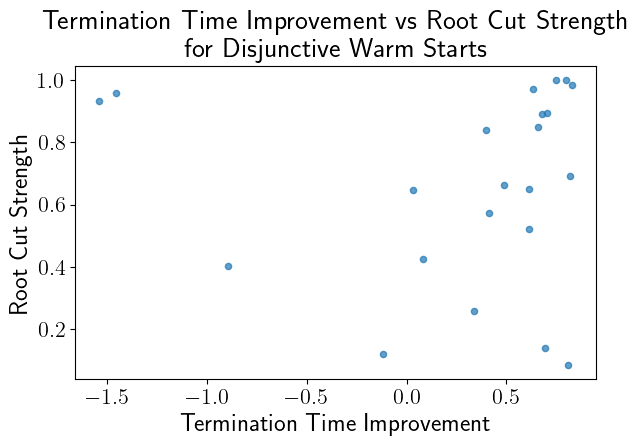

In [100]:
scatter_from_series(time_df["terminationTimeImprovement DisjWarmStart"], time_df["Root Cuts (DisjWarmStart)"],
                    xlabel="Termination Time Improvement", ylabel="Root Cut Strength",
                    title="Termination Time Improvement vs Root Cut Strength\nfor Disjunctive Warm Starts")

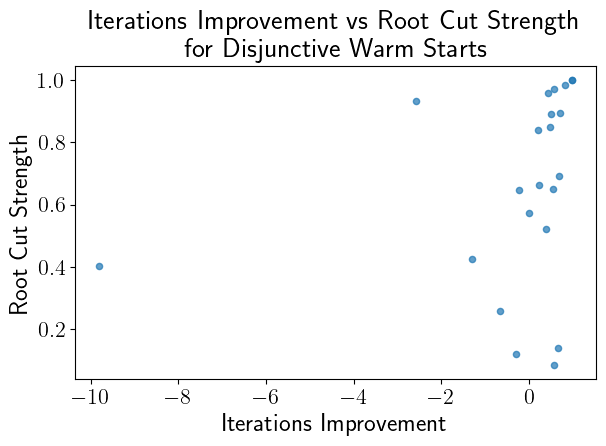

In [103]:
scatter_from_series(time_df["iterationsImprovement DisjWarmStart"], time_df["Root Cuts (DisjWarmStart)"],
                    xlabel="Iterations Improvement", ylabel="Root Cut Strength",
                    title="Iterations Improvement vs Root Cut Strength\nfor Disjunctive Warm Starts")

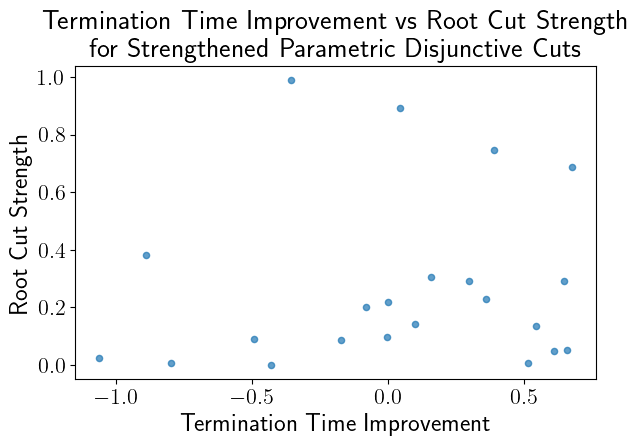

In [101]:
scatter_from_series(time_df["terminationTimeImprovement NoDisjunction"], time_df["Root Cuts (NoDisjunction)"],
                    xlabel="Termination Time Improvement", ylabel="Root Cut Strength",
                    title="Termination Time Improvement vs Root Cut Strength\nfor Strengthened Parametric Disjunctive Cuts")